In [2]:
import pandas as pd

df = pd.read_csv('../data/creditcard.csv')
df.shape

(284807, 31)

In [3]:
X = df.drop('Class', axis=1)
y = df['Class']

X.shape, y.shape

((284807, 30), (284807,))

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()

((227845, 30),
 (56962, 30),
 Class
 0    227451
 1       394
 Name: count, dtype: int64,
 Class
 0    56864
 1       98
 Name: count, dtype: int64)

In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

y_train_smote.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)

c:\Users\paawan\OneDrive\Desktop\5th Sem Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.22        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [9]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train_smote)

y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



In [10]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_smote, y_train_smote)

y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [11]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state=42, eval_metric='logloss')
model_xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.77      0.86      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [12]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('XGBoost'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout(); plt.show()

NameError: name 'plt' is not defined

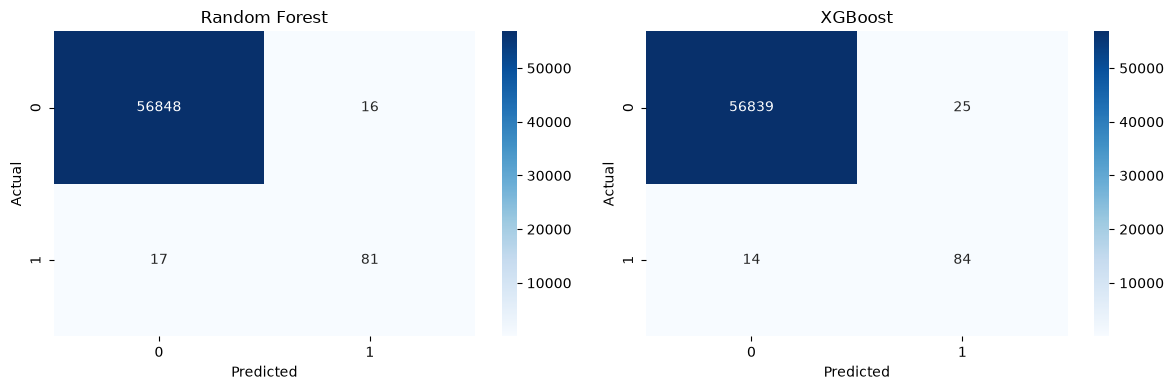

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('XGBoost'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.metrics import average_precision_score

y_prob_lr = model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("Logistic Regression PR-AUC:", average_precision_score(y_test, y_prob_lr))
print("Random Forest PR-AUC:", average_precision_score(y_test, y_prob_xgb))
print("XGBoost PR-AUC:", average_precision_score(y_test, y_prob_xgb))

Logistic Regression PR-AUC: 0.7342312200850297
Random Forest PR-AUC: 0.8775439737326305
XGBoost PR-AUC: 0.8775439737326305


In [ ]:
import numpy as np
np.array_equal(y_prob_rf, y_prob_xgb)

False

In [13]:
from sklearn.metrics import average_precision_score

y_prob_lr = model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("Logistic Regression PR-AUC:", average_precision_score(y_test, y_prob_lr))
print("Random Forest PR-AUC:", average_precision_score(y_test, y_prob_rf))
print("XGBoost PR-AUC:", average_precision_score(y_test, y_prob_xgb))

Logistic Regression PR-AUC: 0.7342312200850297
Random Forest PR-AUC: 0.8746876142969218
XGBoost PR-AUC: 0.8775439737326305


In [14]:
import shap

explainer = shap.TreeExplainer(model_rf)

# Using a sample rather than the full 56,962-row test set — SHAP computation
# gets expensive with many trees and many rows, and 100 is plenty to see real patterns
X_sample = X_test.sample(100, random_state=42)
shap_values = explainer.shap_values(X_sample)

In [15]:
shap_values

array([[[ 0.06286153, -0.06286153],
        [ 0.00094756, -0.00094756],
        [ 0.01384244, -0.01384244],
        ...,
        [ 0.00260373, -0.00260373],
        [-0.00237217,  0.00237217],
        [-0.00539869,  0.00539869]],

       [[ 0.00613066, -0.00613066],
        [ 0.00387504, -0.00387504],
        [ 0.00889115, -0.00889115],
        ...,
        [ 0.00112563, -0.00112563],
        [-0.00472178,  0.00472178],
        [ 0.00267534, -0.00267534]],

       [[ 0.0069211 , -0.0069211 ],
        [ 0.00158379, -0.00158379],
        [ 0.0069101 , -0.0069101 ],
        ...,
        [-0.00193644,  0.00193644],
        [ 0.00064369, -0.00064369],
        [-0.00460193,  0.00460193]],

       ...,

       [[ 0.00621821, -0.00621821],
        [ 0.0016619 , -0.0016619 ],
        [ 0.01180159, -0.01180159],
        ...,
        [ 0.00060332, -0.00060332],
        [ 0.00319753, -0.00319753],
        [ 0.00168352, -0.00168352]],

       [[ 0.00756772, -0.00756772],
        [-0.00403444,  0.00

In [16]:
shap_values_fraud = shap_values[:, :, 1]
shap_values_fraud.shape

(100, 30)

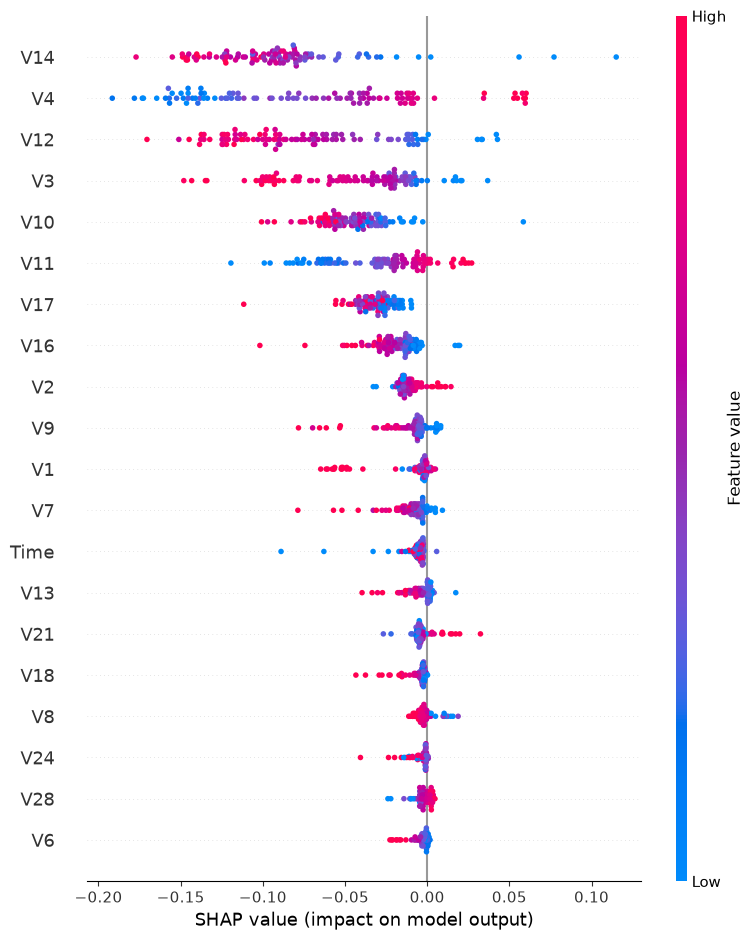

In [17]:
shap.summary_plot(shap_values_fraud, X_sample)